# Documenting Networks 

When publishing results using a reaction network, the species evolved, rates used, and sources for data should be stated, to allow for reproducibility.  pynucastro has some helper functions for this purpose.

We'll create a simple network here to explore these.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "c13",
                           "n13", "n14", "n15",
                           "o14", "o15", "o16", "o18",
                           "f17", "f18", "f19",
                           "ne18", "ne19", "ne20", "ne22"])

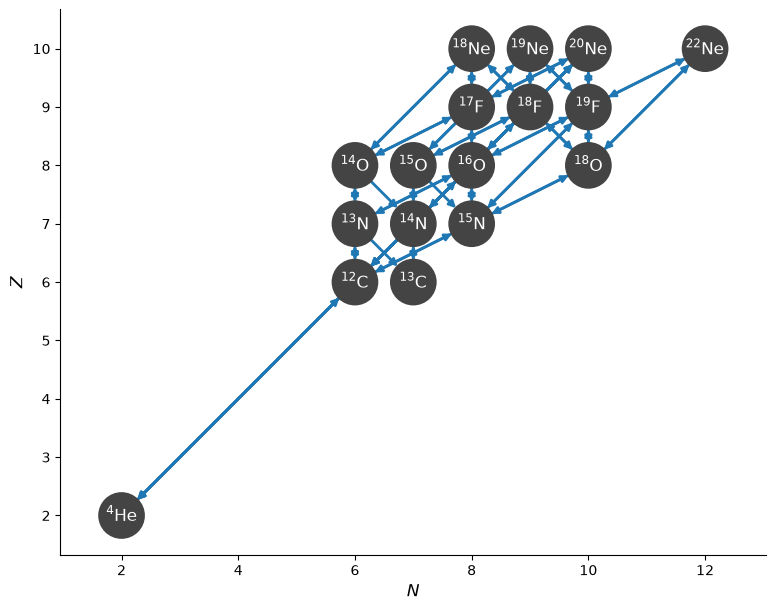

In [3]:
fig = net.plot()

## LaTeX string of nuclei

We can get a LaTeX-formatted string of the nuclei using {py:meth}`get_nuclei_latex_string <pynucastro.networks.rate_collection.RateCollection.get_nuclei_latex_string>`.

In [4]:
s = net.get_nuclei_latex_string()
s

'${}^{1}\\mathrm{H}$, ${}^{4}\\mathrm{He}$, ${}^{12\\mbox{-}13}\\mathrm{C}$, ${}^{13\\mbox{-}15}\\mathrm{N}$, ${}^{14\\mbox{-}16,18}\\mathrm{O}$, ${}^{17\\mbox{-}19}\\mathrm{F}$, ${}^{18\\mbox{-}20,22}\\mathrm{Ne}$'

In Jupyter, we can render this:

In [5]:
from IPython.display import display, Markdown, Math
display(Markdown(s))

${}^{1}\mathrm{H}$, ${}^{4}\mathrm{He}$, ${}^{12\mbox{-}13}\mathrm{C}$, ${}^{13\mbox{-}15}\mathrm{N}$, ${}^{14\mbox{-}16,18}\mathrm{O}$, ${}^{17\mbox{-}19}\mathrm{F}$, ${}^{18\mbox{-}20,22}\mathrm{Ne}$

We see that by default it combines isotopes.

## Table-formatted list of rates

In [6]:
s2 = net.get_rates_latex_table_string()

This is a string where each table row (terminated with the LaTeX newline, ``\\``) is a rate pair (forward and reverse) from the network.
The first row is

In [7]:
print(s2.split(r"\\")[0])

$3 ~{}^{4}\mathrm{He} \rightarrow {}^{12}\mathrm{C}+ \gamma$ &  ${}^{12}\mathrm{C} \rightarrow 3 {}^{4}\mathrm{He}$ 


This full string can be inserted into a LaTeX {\tt tabular} environment containing 2 columns.

To see an example rendering, in Jupyter, we can style it as a math array.

```{note}
The output of `get_rates_latex_table_string` is meant to be used in a LaTeX document.
To get it to render in a Jupyter notebook, we need to use it in a math array environment and:
* remove the explicit ``$`` from the string
* remove the newlines, ``\n``

This is done below just to show an example of the table output

In [15]:
table = rf"""
\begin{{array}}{{ll}}
{s2.replace("$","").replace("\n","")}
\end{{array}}
"""

In [16]:
display(Math(table))

<IPython.core.display.Math object>

## Citing rate sources

Each {py:obj}`Rate <pynucastro.rates.rate.Rate>` object contains a ``source`` dictionary which gives the details of the paper that measured / described the rate.

We can access the details of the source directly from the ``Rate.source`` dictionary, or we can get a set of the unique sources
and then access them.  Here's we'll get the unique sources first:

In [10]:
cites = {r.source["Label"] for r in net.get_rates()}
print(cites)

{'lg06', 'Ha96', 'wh87', 'oda', 'cb09', 'nac2', 'il10', 'nacr', 'ls09', 'ia08', 'im05', 'cf88', 'dc11', 'wc12', 'fy05', 'suzuki', 'li10', 'co10', 'da18'}


This information can further be used with the {py:obj}`RateSource <pynucastro.rates.rate.RateSource>` class to get the information on the publication.

In [11]:
rs = pyna.rates.rate.RateSource

In [12]:
from pprint import pprint

In [13]:
for c in cites:
    pprint(rs.source(c))

{'Author': 'Z.H. Li et al.',
 'Label': 'lg06',
 'Publisher': 'PRC 74, 035801',
 'Title': '<sup>13</sup>N(d,n)<sup>14</sup>O reaction and the astrophysical '
          '<sup>13</sup>N(p,&gamma;)<sup>14</sup>',
 'URL': 'https://doi.org/10.1103/PhysRevC.74.035801',
 'Year': '2006'}
{'Author': 'Hahn, K I',
 'Label': 'Ha96',
 'Publisher': 'PhRvC 54, 4, p1999-2013',
 'Title': 'Structure of 18Ne and the breakout from the hot CNO cycle',
 'URL': 'https://doi.org/10.1103/PhysRevC.54.1999',
 'Year': '1996'}
{'Author': 'M.Wiescher',
 'Label': 'wh87',
 'Publisher': 'ApJ 316, 162-171',
 'Title': 'Alpha-burning of O14',
 'URL': 'https://doi.org/10.1086/165189',
 'Year': '1987'}
{'Author': 'T. Oda, M. Hino, K. Muto, M.Takahara, K. Sato',
 'Label': 'oda',
 'Publisher': 'Atomic Data and Nuclear Data Tables, Volume 56, Issue 2',
 'Title': 'Rate Tables for the Weak Processes of sd-Shell Nuclei in Stellar '
          'Matter',
 'URL': 'https://doi.org/10.1006/adnd.1994.1007',
 'Year': '1994'}
{'Author': '

This information can then be used to add citations to a publication.